**1.Data Loading & Preprocessing**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier


In [ ]:
df = pd.read_csv("/content/Telco_Churn.csv")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


In [ ]:
df.describe()

,Count,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,...,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,36.282441,-119.798880,0.504756,0.162147,0.483033,0.231010,32.371149,0.903166,0.940508,...,0.992475,0.690473,0.592219,1.574329,64.761692,3257.794122,0.265370,0.265370,58.699418,4400.295755
std,0.0,2.455723,2.157889,0.500013,0.368612,0.499748,0.421508,24.559481,0.295752,0.948554,...,0.885091,0.833755,0.491457,1.068104,30.090047,1888.693496,0.441561,0.441561,21.525131,1183.057152
min,1.0,32.555828,-124.301372,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.000000,0.000000,5.000000,2003.000000
25%,1.0,34.030915,-121.815412,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,35.500000,1609.000000,0.000000,0.000000,40.000000,3469.000000
50%,1.0,36.391777,-119.730885,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,...,1.000000,0.000000,1.000000,2.000000,70.350000,3249.000000,0.000000,0.000000,61.000000,4527.000000
75%,1.0,38.224869,-118.043237,1.000000,0.000000,1.000000,0.000000,55.000000,1.000000,2.000000,...,2.000000,1.000000,1.000000,2.000000,89.850000,4901.500000,1.000000,1.000000,75.000000,5380.500000
max,1.0,41.962127,-114.192901,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,2.000000,...,2.000000,2.000000,1.000000,3.000000,118.750000,6530.000000,1.000000,1.000000,100.000000,6500.000000


In [ ]:
df.drop('Churn Reason', axis=1, inplace=True)

In [ ]:
df.drop(['CustomerID','Country','State','City','Zip Code','Lat Long'], axis=1, inplace=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df.drop('Churn Value', axis=1)
y = df['Churn Value']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

**2. Exploratory Data Analysis**

2.1 Churn Distribution

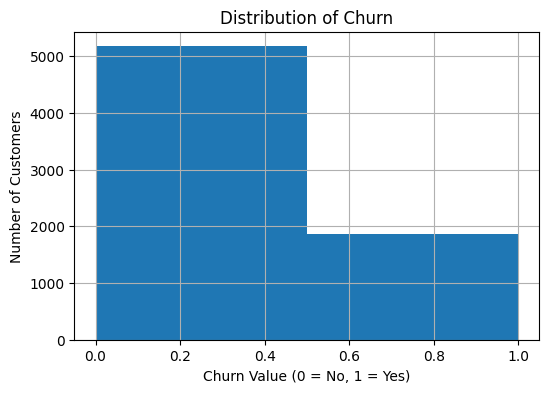

In [ ]:
plt.figure(figsize=(6,4))
df['Churn Value'].hist(bins=2)
plt.title("Distribution of Churn")
plt.xlabel("Churn Value (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()

2.2 Tenure Months Distribution

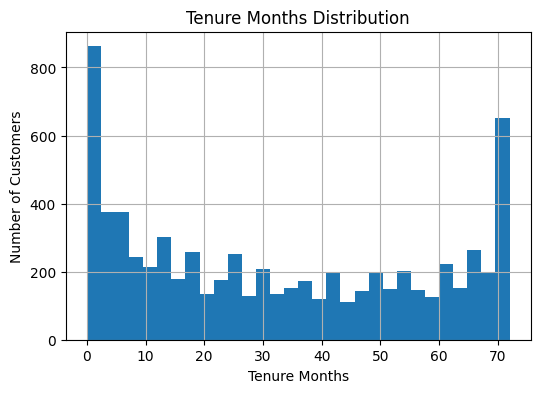

In [ ]:
plt.figure(figsize=(6,4))
df['Tenure Months'].hist(bins=30)
plt.title("Tenure Months Distribution")
plt.xlabel("Tenure Months")
plt.ylabel("Number of Customers")
plt.show()

2.3 Monthly Charges Distribution

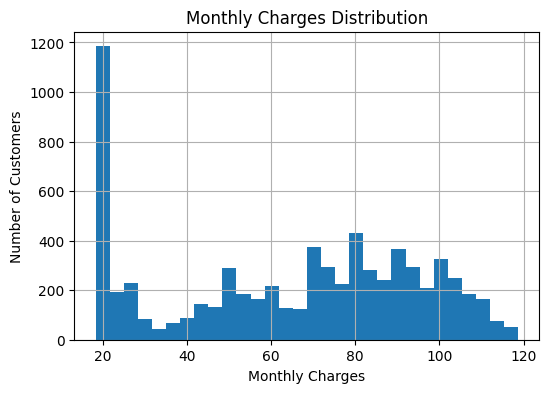

In [ ]:
plt.figure(figsize=(6,4))
df['Monthly Charges'].hist(bins=30)
plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.show()

2.4 Total Charges Distribution

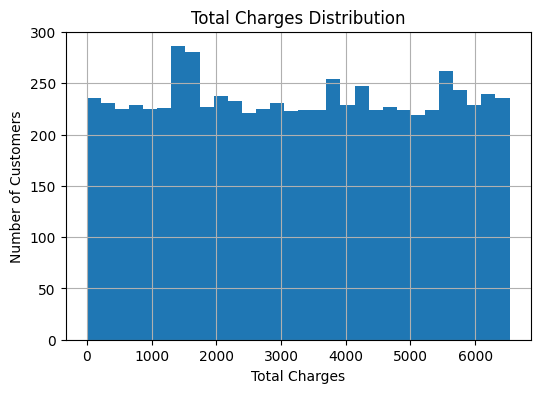

In [ ]:
plt.figure(figsize=(6,4))
df['Total Charges'].hist(bins=30)
plt.title("Total Charges Distribution")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")
plt.show()

2.5 Churn vs Monthly Charges

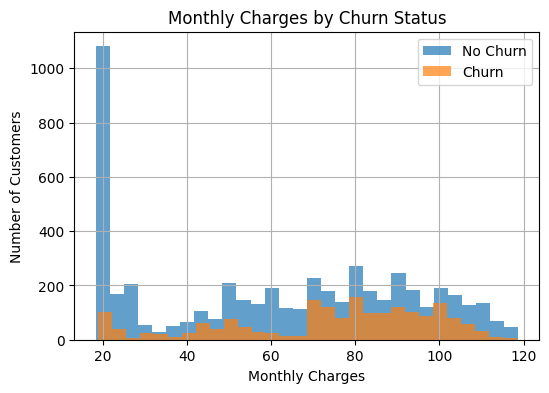

In [ ]:
plt.figure(figsize=(6,4))
df[df['Churn Value'] == 0]['Monthly Charges'].hist(bins=30, alpha=0.7, label='No Churn')
df[df['Churn Value'] == 1]['Monthly Charges'].hist(bins=30, alpha=0.7, label='Churn')
plt.legend()
plt.title("Monthly Charges by Churn Status")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.show()

2.6 Correlation Analysis

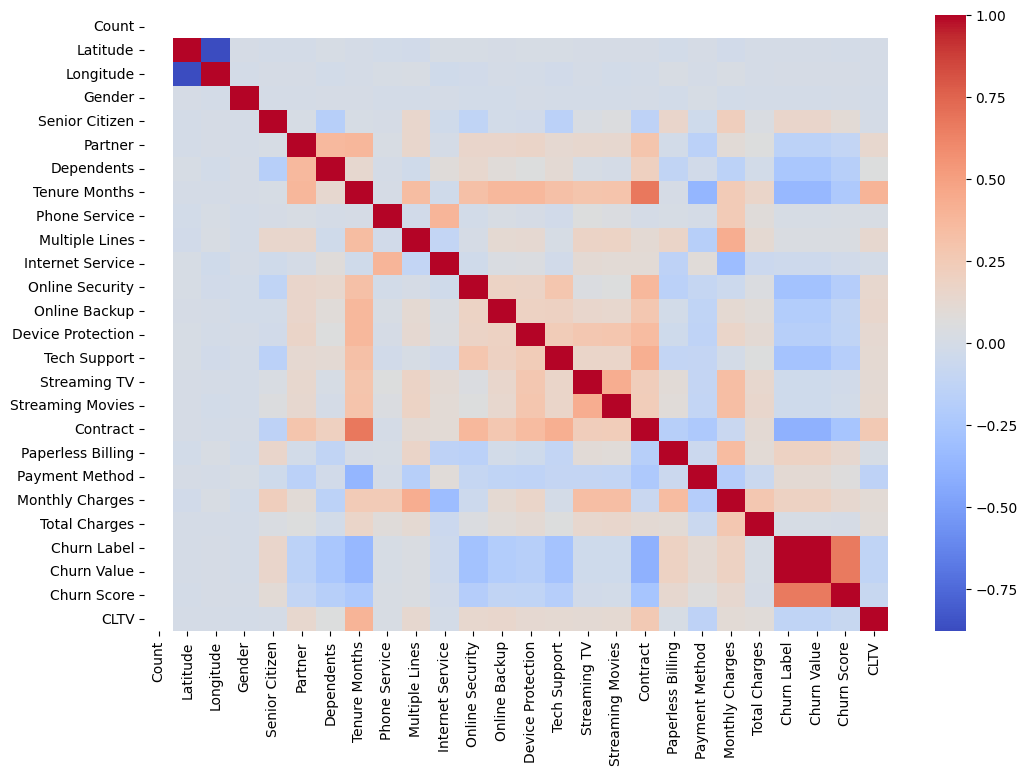

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

**3. Machine Learning Models**

3.1 Logistic Regression Model

In [ ]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [ ]:
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

[[1009    0]
 [   0  400]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1009
           1       1.00      1.00      1.00       400

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409



3.2 Decision Tree Classifier

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [ ]:
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

[[1009    0]
 [   0  400]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1009
           1       1.00      1.00      1.00       400

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409



3.3 Random Forest Classifier

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[1009    0]
 [   0  400]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1009
           1       1.00      1.00      1.00       400

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409



In [ ]:
print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))
print("Decision Tree ROC-AUC:", roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

Logistic Regression ROC-AUC: 1.0
Decision Tree ROC-AUC: 1.0
Random Forest ROC-AUC: 1.0


**4 Neural Network Implementation**



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1)  # shape (n_samples, 1)

# Train-test split tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

# Create PyTorch datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [ ]:
class ChurnNN(nn.Module):
    def __init__(self, input_dim):
        super(ChurnNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 32)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(32, 16)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(16, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x

# Initialize model
input_dim = X_train.shape[1]
model = ChurnNN(input_dim)

In [ ]:
criterion = nn.BCELoss()  # Binary Cross Entropy
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
epochs = 50

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

Epoch [10/50], Loss: 0.0005
Epoch [20/50], Loss: 0.0001
Epoch [30/50], Loss: 0.0000
Epoch [40/50], Loss: 0.0000
Epoch [50/50], Loss: 0.0000


In [ ]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor)
    y_pred_class = (y_pred >= 0.5).float()

    from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

    print("Confusion Matrix:")
    print(confusion_matrix(y_test_tensor, y_pred_class))
    print("\nClassification Report:")
    print(classification_report(y_test_tensor, y_pred_class))
    print("\nROC-AUC Score:", roc_auc_score(y_test_tensor, y_pred.numpy()))

Confusion Matrix:
[[1009    0]
 [   0  400]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1009
         1.0       1.00      1.00      1.00       400

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409


ROC-AUC Score: 1.0
